# Unit 1.1: K-Means Clustering - An Algorithmic and Statistical Primer

### **Objective**
K-Means is a foundational unsupervised learning algorithm designed to partition a dataset into a pre-determined number ($K$) of distinct, non-overlapping clusters. Its primary goal is to group similar data points together while maximizing the separation between different clusters. The "similarity" is measured based on the distance of data points to a central point in each cluster, known as the **centroid**.

### **The Algorithm**
The K-Means algorithm operates iteratively to find the optimal placement of $K$ centroids. The process minimizes the **Within-Cluster Sum of Squares (WCSS)**, also known as **inertia**.

The iterative steps are as follows:
1.  **Initialization:** $K$ initial centroids are chosen. A naive approach is to select $K$ random data points. A more robust method, `k-means++`, selects initial centroids that are strategically distant from one another to improve convergence.
2.  **Assignment Step:** Each data point in the dataset is assigned to the cluster corresponding to its nearest centroid. The most common distance metric used is the squared Euclidean distance.
3.  **Update Step:** The position of each of the $K$ centroids is recalculated. The new position is the mean of all data points assigned to that centroid in the previous step.
4.  **Convergence:** Steps 2 and 3 are repeated until the cluster assignments no longer change or the centroids cease to move significantly. The algorithm has then converged to a solution.

### **Mathematical Formulation**
The objective function that K-Means seeks to minimize is the WCSS ($J$):

$$J = \sum_{j=1}^{K} \sum_{i \in C_j} ||x_i - \mu_j||^2$$

Where:
- $K$ is the total number of clusters.
- $C_j$ is the set of all data points belonging to cluster $j$.
- $x_i$ is a data point.
- $\mu_j$ is the centroid of cluster $j$.
- $||x_i - \mu_j||^2$ is the squared Euclidean distance between the data point $x_i$ and the centroid $\mu_j$.

### **Key Parameters & Considerations**
- **`n_clusters` (K):** The most critical parameter. The number of clusters must be specified beforehand. The **Elbow Method** is a common heuristic used to estimate an optimal value for $K$.
- **`init`:** The centroid initialization method. It is highly recommended to use `'k-means++'` instead of `'random'` to avoid poor convergence due to unlucky initial placements.
- **`n_init`:** The number of times the algorithm will be run with different random centroid initializations. The final result will be the best output in terms of inertia. A value of `10` is standard practice.

### **Assumptions and Limitations**
K-Means is effective but relies on several implicit assumptions about the data:
1.  **Spherical Cluster Shape:** The use of Euclidean distance assumes clusters are spherical (isotropic). It performs poorly on elongated or irregularly shaped clusters.
2.  **Similar Cluster Size:** The algorithm tends to produce clusters of similar size and density.
3.  **No Overlapping Clusters:** K-Means performs a "hard" assignment, meaning each point belongs to exactly one cluster. It cannot model overlapping cluster structures.

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load and inspect the data
mall_url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/machine_learning/unsupervised_learning/data/Mall_Customers.csv"
data = pd.read_csv(mall_url, usecols=lambda col: not col.startswith("Unnamed"))
X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

In [ ]:
from sklearn.cluster import KMeans

# This creates an array [1, 2, 3, ..., 10] to test different numbers of clusters
k_range = np.arange(1, 11)

# Compute Within-Cluster Sum of Squares (WCSS) for each K in k_range
# Parameters: n_clusters=K, init='k-means++' for better initialization, n_init=10 for multiple runs, random_state=42 for reproducibility
wcss = [
    KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42).fit(X).inertia_
    for k in k_range
]

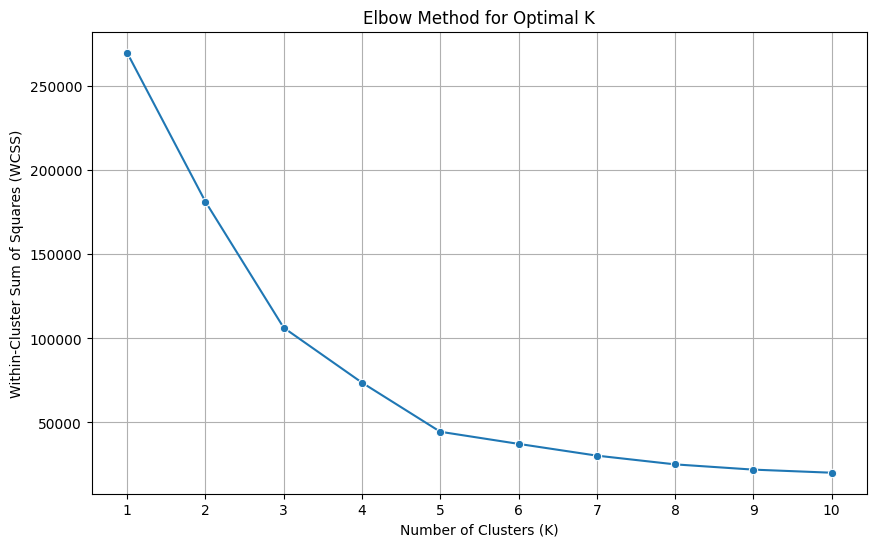

In [ ]:
# The Elbow Method visualizes WCSS (Within-Cluster Sum of Squares) vs. number of clusters (K) to identify optimal K where WCSS decreases sharply then flattens
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    x=list(k_range), y=wcss, marker="o", ax=ax
)  # Plot WCSS values against K range using Seaborn's lineplot;
ax.set_title("Elbow Method for Optimal K")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Within-Cluster Sum of Squares (WCSS)")
ax.set_xticks(
    list(k_range)
)  # Explicitly set x-axis ticks to match the K values for clarity
ax.grid(True)
plt.show()

In [ ]:
k_optimal = 5

# Initialize the K-Means clustering model with K=5 clusters
# - init='k-means++': Uses a smart initialization strategy to select initial centroids that are far apart, improving convergence and avoiding poor local minima
# - n_init=10: Runs the algorithm 10 times with different random initializations and selects the best result based on inertia (WCSS), enhancing robustness
# - random_state=42: Ensures reproducibility by fixing the random seed for consistent results across runs
kmeans_final = KMeans(
    n_clusters=k_optimal, init="k-means++", n_init=10, random_state=42
)

# fit_predict() combines fitting (learning centroids) and predicting (assigning clusters) in one step, returning an array of cluster indices (0 to K-1)
y_kmeans = kmeans_final.fit_predict(X)

# Add the predicted cluster labels as a new column 'Cluster' to the original data DataFrame
data["Cluster"] = y_kmeans

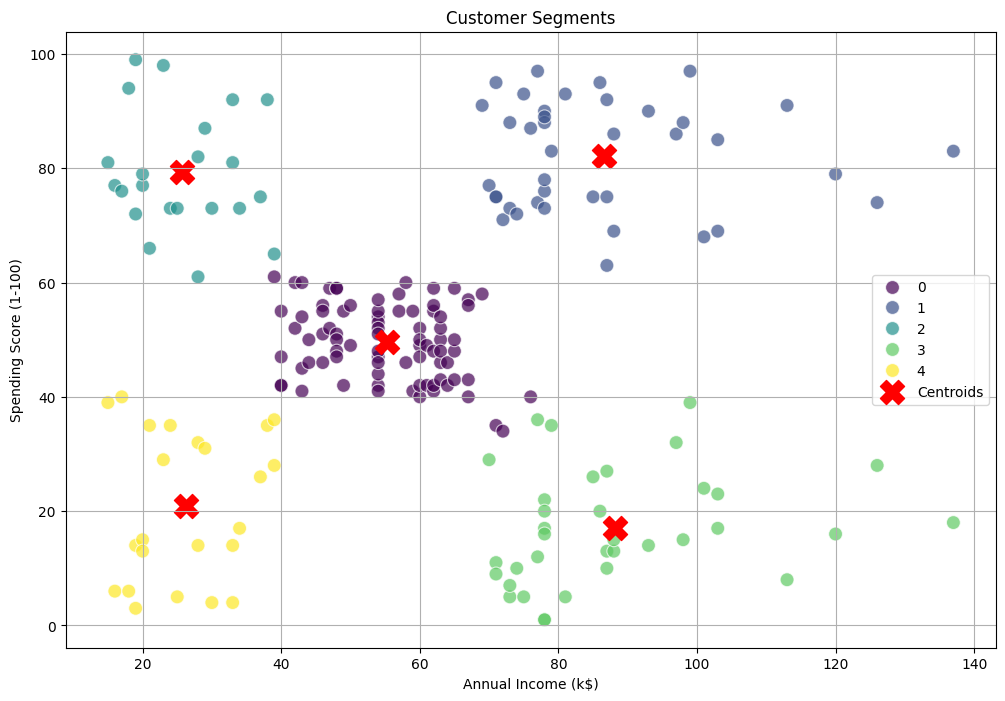

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Seaborn's scatterplot() displays data points with x and y coordinates from the DataFrame
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    data=data,
    palette="viridis",
    s=100,
    alpha=0.7,
    legend="full",
    ax=ax,
)

# Extract centroids from the fitted K-Means model; cluster_centers_ is a 2D array of centroid coordinates
centroids = kmeans_final.cluster_centers_

# Overlay centroids on the plot using Matplotlib's scatter(); centroids[:, 0] and [:, 1] are x and y coordinates
# s=300 enlarges markers; c="red" sets color; marker="X" uses an X shape; label adds to legend
ax.scatter(
    centroids[:, 0], centroids[:, 1], s=300, c="red", marker="X", label="Centroids"
)

# Set plot title, axis labels, and enable legend and grid for clarity
ax.set_title("Customer Segments")
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")
ax.legend()
ax.grid(True)
plt.show()

In [13]:
wholesale_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
wholesale = pd.read_csv(
    wholesale_url, usecols=lambda col: not col.startswith("Unnamed")
)

In [14]:
wholesale

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [15]:
X = wholesale.drop(["Channel", "Region"], axis=1)

In [16]:
X.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
from sklearn.cluster import KMeans

# This creates an array [1, 2, 3, ..., 10] to test different numbers of clusters
k_range = np.arange(1, 11)

# Compute Within-Cluster Sum of Squares (WCSS) for each K in k_range
# Parameters: n_clusters=K, init='k-means++' for better initialization, n_init=10 for multiple runs, random_state=42 for reproducibility
wcss = [
    KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    .fit(X_scaled)
    .inertia_
    for k in k_range
]

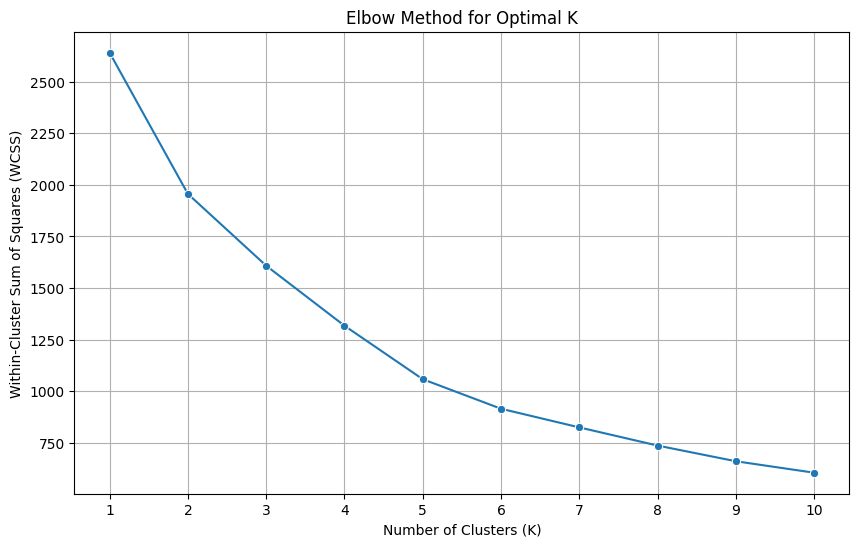

In [20]:
# The Elbow Method visualizes WCSS (Within-Cluster Sum of Squares) vs. number of clusters (K) to identify optimal K where WCSS decreases sharply then flattens
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    x=list(k_range), y=wcss, marker="o", ax=ax
)  # Plot WCSS values against K range using Seaborn's lineplot;
ax.set_title("Elbow Method for Optimal K")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Within-Cluster Sum of Squares (WCSS)")
ax.set_xticks(
    list(k_range)
)  # Explicitly set x-axis ticks to match the K values for clarity
ax.grid(True)
plt.show()

In [21]:
k_optimal = 6

# Initialize the K-Means clustering model with K=5 clusters
# - init='k-means++': Uses a smart initialization strategy to select initial centroids that are far apart, improving convergence and avoiding poor local minima
# - n_init=10: Runs the algorithm 10 times with different random initializations and selects the best result based on inertia (WCSS), enhancing robustness
# - random_state=42: Ensures reproducibility by fixing the random seed for consistent results across runs
kmeans_final = KMeans(
    n_clusters=k_optimal, init="k-means++", n_init=10, random_state=42
)

# fit_predict() combines fitting (learning centroids) and predicting (assigning clusters) in one step, returning an array of cluster indices (0 to K-1)
y_kmeans = kmeans_final.fit_predict(X_scaled)

# Add the predicted cluster labels as a new column 'Cluster' to the original data DataFrame
wholesale["Cluster"] = y_kmeans

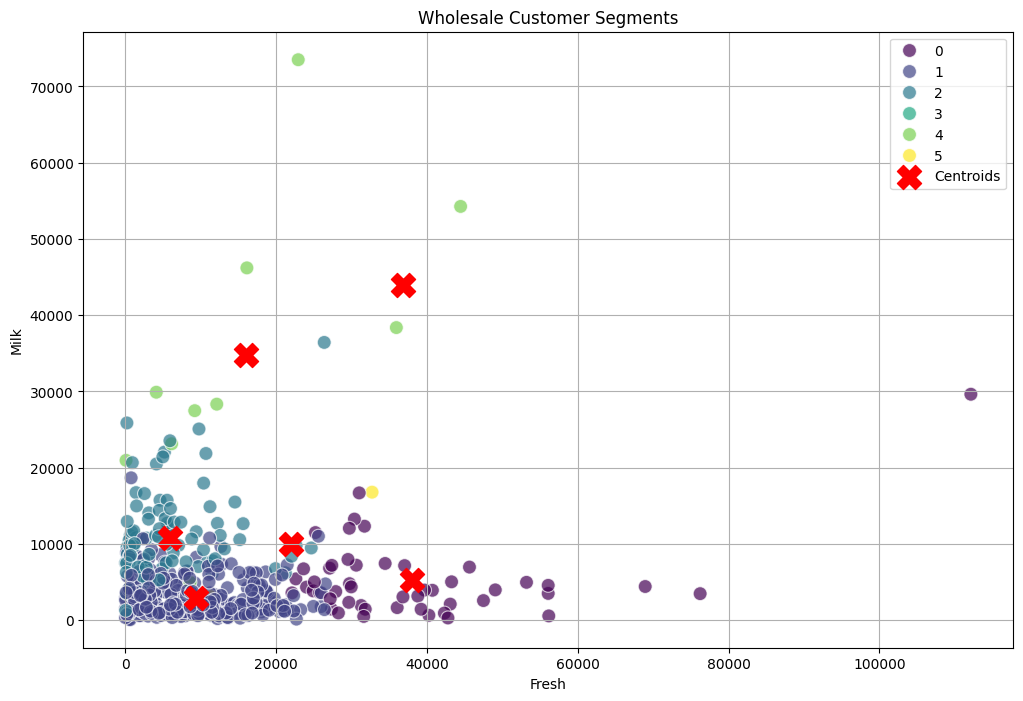

In [22]:
fig, ax = plt.subplots(figsize=(12, 8))

# Seaborn's scatterplot() displays data points with x and y coordinates from the DataFrame
sns.scatterplot(
    x="Fresh",
    y="Milk",
    hue="Cluster",
    data=wholesale,
    palette="viridis",
    s=100,
    alpha=0.7,
    legend="full",
    ax=ax,
)

# Extract centroids from the fitted K-Means model; cluster_centers_ is a 2D array of centroid coordinates in scaled space
centroids_scaled = kmeans_final.cluster_centers_

# Inverse transform centroids to original scale for plotting
centroids = scaler.inverse_transform(centroids_scaled)

# Overlay centroids on the plot using Matplotlib's scatter(); centroids[:, 0] and [:, 1] are x and y coordinates (Fresh and Milk)
# s=300 enlarges markers; c="red" sets color; marker="X" uses an X shape; label adds to legend
ax.scatter(
    centroids[:, 0], centroids[:, 1], s=300, c="red", marker="X", label="Centroids"
)

# Set plot title, axis labels, and enable legend and grid for clarity
ax.set_title("Wholesale Customer Segments")
ax.set_xlabel("Fresh")
ax.set_ylabel("Milk")
ax.legend()
ax.grid(True)
plt.show()

### PCA Reduction to properly visualise the clustering

In [23]:
# Import the PCA class from scikit-learn's decomposition module
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

# Use the PCA object to learn from and transform our scaled 6D data into 2D
X_pca = pca.fit_transform(X_scaled)

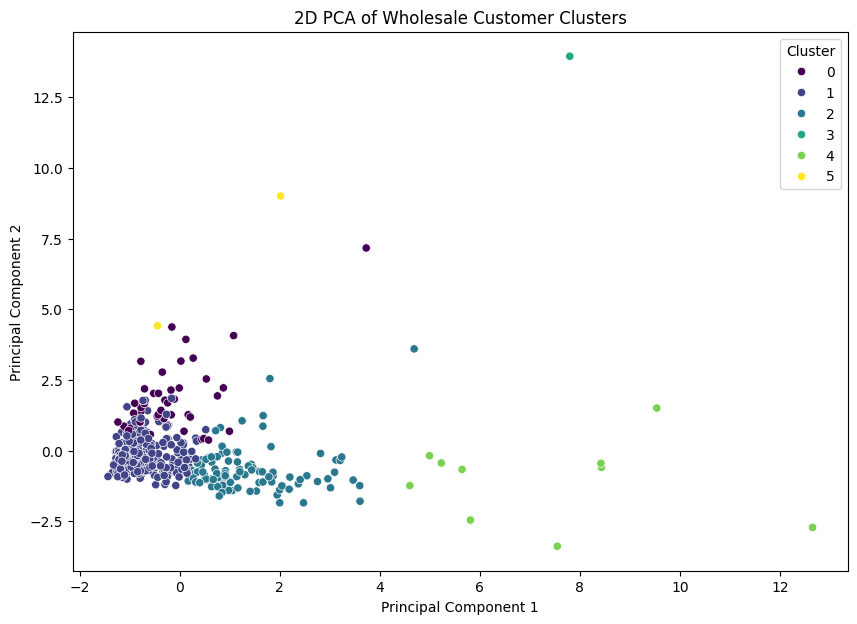

In [25]:
# For easier plotting, let's put the PCA results into a DataFrame
df_pca = pd.DataFrame(
    data=X_pca, columns=["Principal Component 1", "Principal Component 2"]
)

# Add the cluster labels that we found using K-Means on the full 6D data
# Assuming your K-Means model is called 'kmeans_final'
df_pca["Cluster"] = kmeans_final.labels_

# Now, create the scatter plot using object-oriented interface
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Cluster",
    data=df_pca,
    palette="viridis",
    ax=ax,
)
ax.set_title("2D PCA of Wholesale Customer Clusters")
plt.show()

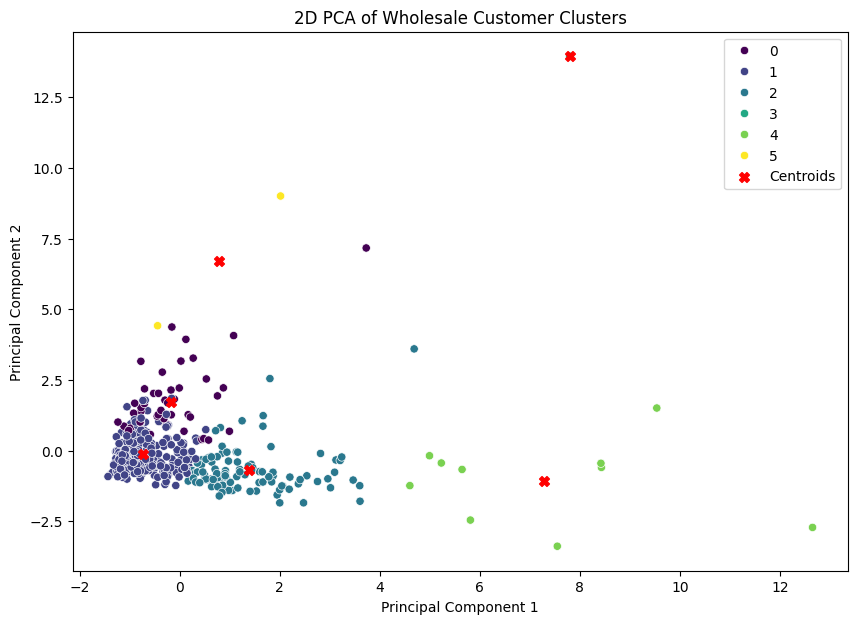

In [27]:
# 1. Get the centroids in their original 6D scaled space (as before)
centroids_scaled = kmeans_final.cluster_centers_

# 2. Use your FITTED pca object to transform the 6D centroids into 2D PCA space
#    We use .transform() because the PCA rules have already been learned from the data.
centroids_pca = pca.transform(centroids_scaled)

# --- Now, add the centroids to your existing plot code ---

# Create the scatter plot for the data points (as you've already done)
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Cluster",
    data=df_pca,
    palette="viridis",
    ax=ax,
)
ax.set_title("2D PCA of Wholesale Customer Clusters")

# 3. Plot the TRANSFORMED centroids on the same axes
#    The x-coordinate is the first column of centroids_pca, and the y-coordinate is the second.
ax.scatter(
    x=centroids_pca[:, 0],
    y=centroids_pca[:, 1],
    s=50,  # Make them large
    c="red",  # Make them a distinct color
    marker="X",  # Use a distinct marker
    label="Centroids",  # Add to the legend
)
ax.legend()
plt.show()

## Cluster Validation - Measuring the Quality of Unsupervised Results

### **Objective**
The most significant challenge in clustering is that we typically do not have a "ground truth" label to measure our accuracy against. Therefore, we cannot simply calculate a percentage of correct assignments. We must instead use **intrinsic validation metrics** to assess the quality of the clusters based on the geometric properties of the partitioning itself. The fundamental questions these metrics seek to answer are:
1.  Are the clusters internally cohesive? (i.e., are the points within a cluster close to each other?)
2.  Are the clusters externally distinct? (i.e., are different clusters far apart from each other?)

A good clustering result is one that maximizes inter-cluster distance while minimizing intra-cluster distance.

### **Intrinsic Validation Metrics**

#### **1. The Silhouette Score**
This is one of the most popular and intuitive clustering validation metrics. It provides a measure of how well each data point fits within its assigned cluster.

* **Conceptual Core:** For each data point, the silhouette score compares its average distance to points in its own cluster with its average distance to points in the *next nearest* cluster.

* **Calculation for a Single Point:**
    1.  **`a` (Cohesion):** Calculate the mean distance between the point and all other points in the **same cluster**. A small `a` is desirable.
    2.  **`b` (Separation):** Calculate the mean distance between the point and all points in the **next nearest cluster** (the neighboring cluster to which it is closest). A large `b` is desirable.

* **The Formula:** The silhouette score `s` for a single data point is:
    $$s = \frac{b - a}{\max(a, b)}$$

* **Interpretation:**
    The score ranges from **-1 to +1**. The overall Silhouette Score for a model is the average of `s` across all data points.
    * **Score approaching +1:** Indicates that the point is well-matched to its own cluster and poorly-matched to neighboring clusters. This is the ideal.
    * **Score of 0:** Indicates that the point is on or very close to the decision boundary between two clusters.
    * **Score approaching -1:** Indicates that the point is likely assigned to the wrong cluster and is, on average, closer to the neighboring cluster.

* **Practical Use:** The Silhouette Score is used to compare clustering results for different values of *K*. The value of *K* that yields the highest average silhouette score is often considered the optimal choice.

#### **2. Davies-Bouldin Index**
This metric is based on a ratio of within-cluster scatter to between-cluster separation.

* **Conceptual Core:** It computes the average similarity between each cluster and its most similar one. Similarity is defined as the ratio of the sum of within-cluster distances to the distance between the cluster centroids.
* **Interpretation:** The score starts at 0, with lower values indicating better clustering. A score of 0 represents a perfect clustering where all clusters are infinitely dense and separated. Therefore, when comparing different values of *K*, you should choose the one with the **lowest Davies-Bouldin score**.

#### **3. Calinski-Harabasz Index (Variance Ratio Criterion)**
This index is defined as the ratio of the sum of between-cluster dispersion to the sum of within-cluster dispersion for all clusters.

* **Conceptual Core:** It measures how much more variance there is *between* the clusters compared to the variance *within* them. We want clusters to be very far apart (high between-cluster variance) and very dense (low within-cluster variance).
* **Interpretation:** Because it is a ratio, a **higher Calinski-Harabasz score indicates a better clustering performance**. There is no upper bound on the score.

### **Summary of Metrics**

| Metric | Ideal Score | Primary Focus |
| :--- | :---: | :--- |
| **Silhouette Score** | Close to **+1** | Cohesion vs. Separation |
| **Davies-Bouldin Index**| Close to **0** | Ratio of within-cluster to between-cluster distance |
| **Calinski-Harabasz Index**| **Higher is better**| Ratio of between-cluster to within-cluster variance |

In [30]:
# Group by the 'Cluster' label and calculate the mean for all features
cluster_profiles = wholesale.groupby("Cluster").mean()

# Add the size of each cluster
cluster_sizes = wholesale["Cluster"].value_counts().sort_index()
cluster_profiles["Size"] = cluster_sizes

# Round all values to the nearest whole number and convert to integer type
cluster_profiles_rounded = cluster_profiles.round(0).astype(int)


# Display the clean, rounded audit dataframe
print("Cluster Profiles (Rounded Mean Annual Spending per Category):")
display(cluster_profiles_rounded)

Cluster Profiles (Rounded Mean Annual Spending per Category):


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Size
Cluster,,,,,,,,,
0,1,3,37979,5245,5986,6017,989,2367,49
1,1,3,9304,2969,3782,2668,962,997,280
2,2,3,5853,10725,16581,1499,7139,1941,98
3,1,3,36847,43950,20170,36534,239,47943,1
4,2,2,15965,34708,48537,3055,24875,2943,10
5,1,2,22016,9937,7844,47939,672,4154,2


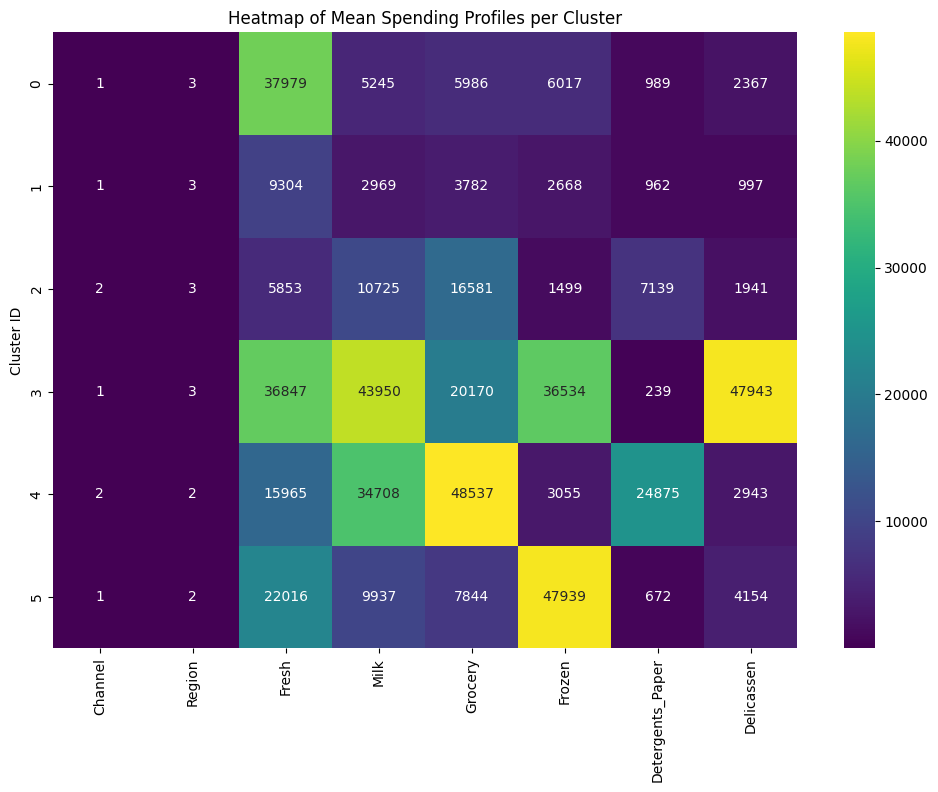

In [32]:
# We don't need to include 'Size' in the heatmap itself
profile_for_heatmap = cluster_profiles.drop(columns=["Size"])


fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    profile_for_heatmap,
    annot=True,
    fmt=".0f",  # Format numbers as integers
    cmap="viridis",
    ax=ax,
)
ax.set_title("Heatmap of Mean Spending Profiles per Cluster")
ax.set_ylabel("Cluster ID")
plt.show()